# Домашнее задание 3

### ИАД. 2025-2026

### Прогнозирование временных рядов

Мы постарались составить домашнее задание так, чтобы оно помогло закрепить все то, что мы прошли на лекциях и семинарах. Вы вольны использовать любые библиотеки, которые вам нравятся. Главное — это осознанность в выборе методов и интерпретации выводов.

В рамках домашнего задания будем работать с датасетом `NN5`, который можно скачать [здесь](https://zenodo.org/records/4656117). Временные ряды в этом датасете представляют собой данные по ежедневным снятиям наличных в банкоматах в Великобритании.

### Задание 1. Первичный анализ данных (1 балл)

In [2]:
!pip install statsforecast==2.0.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 631.3 kB/s  0:00:47a 0:00:010:00:02:02
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
  Attempting uninstall: narwhals━━━━━━━━━━━━━━━━━━━━━━ 0/8 [scipy]
    Found existing installation: narwhals 1.31.0━━ 0/8 [scipy]
    Uninstalling narwhals-1.31.0:━━━━━━━━━━━━━━━━━ 0/8 [scipy]
      Successfully uninstalled narwhals-1.31.0━━━━ 0/8 [scipy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [statsforecast]m 6/8 [fugue]orecast]


In [1]:
import logging

logger = logging.getLogger(__name__)
import sys

c_handler = logging.StreamHandler(sys.stdout)
logger.addHandler(c_handler)
logging.basicConfig(level=logging.INFO, force=True)

import random
import warnings
from datetime import datetime
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from statsforecast import StatsForecast, models
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

INFO:numexpr.utils:NumExpr defaulting to 12 threads.


In [2]:
def mase(
    forecast: np.ndarray,
    insample: np.ndarray,
    outsample: np.ndarray,
    frequency: int,
) -> np.ndarray:
    """MASE loss as defined in "Scaled Errors" https://robjhyndman.com/papers/mase.pdf

    Args:
        forecast: Forecast values. Shape: batch, time_o
        insample: Insample values. Shape: batch, time_i
        outsample: Target values. Shape: batch, time_o
        frequency: Frequency value
    Returns:
        Same shape array with error calculated for each time step
    """
    return np.mean(np.abs(forecast - outsample)) / np.mean(
        np.abs(insample[:-frequency] - insample[frequency:])
    )

Нам пригодятся уже знакомые функции с семинаров по чтению рядов в формате tsf. Напомню, что иногда временные ряды могут быть представлены в tsf формате. Это такая структура данных, которая позволяет хранить метаинформацию о временных рядах, а также пары "первая дата — все значения временного ряда".

Функции позволяют считать данные в tsf формате и перевести их в формат, которым мы можем пользоваться.

In [3]:
def convert_tsf_to_dataframe(
    full_file_path_and_name: str,
    replace_missing_vals_with: Any = "NaN",
    value_column_name: str = "series_value",
) -> tuple[pd.DataFrame, str, int, str, str]:
    """
    Конвертирует файл формата TSF в pandas DataFrame.

    Args:
        full_file_path_and_name: Путь к файлу формата TSF.
        replace_missing_vals_with: Значение для замены пропусков.
        value_column_name: Имя столбца для значений временных рядов.

    Returns:
        DataFrame с данными временных рядов.
        Частота данных.
        Прогнозируемый горизонт.
        Содержат ли данные пропуски.
        Равны ли длины временных рядов.

    """
    col_names = []
    col_types = []
    all_data = {}
    all_series = []
    frequency = None
    forecast_horizon = None
    contain_missing_values = None
    contain_equal_length = None
    data_started = False

    with open(full_file_path_and_name, "r", encoding="cp1252") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            if line.startswith("@"):
                if line.startswith("@data"):
                    data_started = True
                    # Инициализируем словарь для данных атрибутов
                    for col in col_names:
                        all_data[col] = []
                else:
                    parts = line.split(" ")
                    if line.startswith("@attribute"):
                        col_names.append(parts[1])
                        col_types.append(parts[2])
                    elif line.startswith("@frequency"):
                        frequency = parts[1]
                    elif line.startswith("@horizon"):
                        forecast_horizon = int(parts[1])
                    elif line.startswith("@missing"):
                        contain_missing_values = parts[1].lower() in (
                            "y",
                            "yes",
                            "t",
                            "true",
                            "on",
                            "1",
                        )
                    elif line.startswith("@equallength"):
                        contain_equal_length = parts[1].lower() in (
                            "y",
                            "yes",
                            "t",
                            "true",
                            "on",
                            "1",
                        )
            elif not line.startswith("#") and data_started:
                parts = line.split(":")
                # Последняя часть содержит значения ряда
                series_vals = parts[-1].split(",")
                numeric_series = [
                    replace_missing_vals_with if val == "?" else float(val) for val in series_vals
                ]
                all_series.append(pd.Series(numeric_series).array)
                # Преобразуем и сохраняем значения атрибутов
                for i in range(len(col_names)):
                    if col_types[i] == "numeric":
                        all_data[col_names[i]].append(int(parts[i]))
                    elif col_types[i] == "string":
                        all_data[col_names[i]].append(parts[i])
                    elif col_types[i] == "date":
                        all_data[col_names[i]].append(
                            datetime.strptime(parts[i], "%Y-%m-%d %H-%M-%S")
                        )

    all_data[value_column_name] = all_series
    loaded_data = pd.DataFrame(all_data)
    return loaded_data, frequency, forecast_horizon, contain_missing_values, contain_equal_length


def date_to_daterange(x: pd.Series, freq: str) -> pd.Series:
    """
    Преобразует временные метки в диапазон дат.

    Args:
        x: Временные метки.
        freq: Частота.

    Returns:
        pd.Series с диапазоном дат.

    """
    return pd.Series(pd.date_range(start=x.iloc[0], periods=len(x), freq=freq))


def convert_tsf_to_multivariate_or_standard_format(
    tsf_data_path: str,
    target_column: str = "series_value",
    date_from_column: str = "start_timestamp",
    id_column: str = "series_name",
    # one from ["multivariate", "standard"]
    format: str = "multivariate",
) -> pd.DataFrame:
    """
    Преобразует данные формата TSF в формат pandas DataFrame:
        если format == "standard" -> датафрейм с колонками "id", "date" и "value"
        если format == "multivariate" -> pivot таблица c date в качестве индекса,
            id в качестве колонок и значениями из value_column_name

    Args:
        tsf_data_path: Путь к файлу формата TSF.
        target_column: Имя столбца с целевой переменной.
        date_from_column: Имя столбца с переменной дат.
        id_column: Имя столбца с идентификаторами временных рядов.
        format: Формат данных ("multivariate" или "standard").

    Returns:
        pd.DataFrame с данными в формате "id", "date" и "value".

    """
    FREQ_MAP = {
        "monthly": "MS",
        "10_minutes": "10min",
        "half_hourly": "30min",
        "minutely": "1min",
        "daily": "D",
        "weekly": "7D",
        "yearly": "YS",
        "quarterly": "QS",
        "hourly": "H",
    }

    tsf_df, freq = convert_tsf_to_dataframe(tsf_data_path)[:2]

    # Преобразуем списки в {target_column} в "длинный столбец" со значениями
    tsf_df = tsf_df.explode(target_column)
    # Заменим повторяющиеся значения даты в {date_column} на date_range
    tsf_df["date"] = (
        tsf_df.groupby(id_column, sort=False)[date_from_column]
        .apply(lambda x: date_to_daterange(x, FREQ_MAP[freq]))
        .values
    )
    tsf_df = tsf_df.drop(columns=date_from_column)
    # Переименуем колонки
    tsf_df = tsf_df.rename(columns={id_column: "id", target_column: "value"}).reset_index(
        drop=True
    )
    # Приведем {id_column} к численным значениям
    ids2num = dict(zip(tsf_df["id"].unique(), np.arange(tsf_df["id"].nunique())))
    tsf_df["id"] = tsf_df["id"].map(ids2num)

    if format == "standard":
        return tsf_df
    return pd.pivot_table(tsf_df, values="value", index="date", columns="id")

#### Задание 1.1: Загрузка данных (0 баллов)

Давайте скачаем датасет __NN5__ и загрузим его, воспользовавшись функцией `convert_tsf_to_multivariate_or_standard_format`.

In [4]:
!wget "https://zenodo.org/records/4656117/files/nn5_daily_dataset_without_missing_values.zip?download=1" -O nn5_daily_dataset_without_missing_values.zip
!unzip -o nn5_daily_dataset_without_missing_values.zip
!rm nn5_daily_dataset_without_missing_values.zip

--2026-06-11 21:12:05--  https://zenodo.org/records/4656117/files/nn5_daily_dataset_without_missing_values.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 188.184.103.118, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 289779 (283K) [application/octet-stream]
Saving to: ‘nn5_daily_dataset_without_missing_values.zip’

nn5_daily_dataset_w 100%[===================>] 282.99K   534KB/s    in 0.5s    

2026-06-11 21:12:06 (534 KB/s) - ‘nn5_daily_dataset_without_missing_values.zip’ saved [289779/289779]

Archive:  nn5_daily_dataset_without_missing_values.zip
  inflating: nn5_daily_dataset_without_missing_values.tsf  


In [5]:
df = convert_tsf_to_multivariate_or_standard_format(
    "nn5_daily_dataset_without_missing_values.tsf", format="standard"
)
df.head()

,id,value,date
0,0,13.407029,1996-03-18
1,0,14.725057,1996-03-19
2,0,20.564059,1996-03-20
3,0,34.70805,1996-03-21
4,0,26.629819,1996-03-22


#### Задание 1.2: Типы данных (0.3 балла)

Выведите типы данных в датасете. Проверьте, что они корректные: даты должны быть в формате datetime, id — object, а значения временных рядов — float. Если это не так, то исправьте их.

In [6]:
# --- Your code here ---
df.dtypes

id                int64
value            object
date     datetime64[ns]
dtype: object

In [7]:
df['id'] = df['id'].astype(object)
df['value'] = df['value'].astype(float)

df.dtypes

id               object
value           float64
date     datetime64[ns]
dtype: object

#### Задание 1.3: Пропуски (0.05 балла)

Проверьте, есть ли в данных пропуски. Если они есть, то заполните их предыдущими значениями. Если пропусков нет, то просто выведите сообщение об этом.

In [8]:
# --- Your code here ---
if df.isna().any().any():
    for col in df.columns:
        if df[col].isna().any:
            df[col] = df[col].fillna(method='ffill')
else:
    print('Пропусков нет')

Пропусков нет


#### Задание 1.4: Визуальный анализ временных рядов (0.4 балла)

Постройте линейные графики временных рядов. По оси X отложите время, по оси Y — значения временного ряда.

Используйте Plotly, чтобы можно было отложить сразу все временные ряды на одном графике.

In [9]:
df.head()

,id,value,date
0,0,13.407029,1996-03-18
1,0,14.725057,1996-03-19
2,0,20.564059,1996-03-20
3,0,34.708050,1996-03-21
4,0,26.629819,1996-03-22


In [47]:
# --- Your code here ---
fig = go.Figure()
for id, group in df.groupby('id'):
    fig.add_trace(go.Line(
        x=group['date'],
        y=group['value'],
        name=id
    ))

fig.update_layout(legend_title_text = "ID ряда", title = "Временные ряды датасета NN5")
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Значение")

fig.show()

/Users/ashentide/anaconda3/lib/python3.13/site-packages/plotly/graph_objs/_deprecations.py:378: DeprecationWarning:

plotly.graph_objs.Line is deprecated.
Please replace it with one of the following more specific types
  - plotly.graph_objs.scatter.Line
  - plotly.graph_objs.layout.shape.Line
  - etc.




__Ответьте на следующие вопросы:__
- Какова частотность (frequency) данных?
- Выровнены ли временные ряды?
- Стационарны ли временные ряды? Если нет, то какие признаки нестационарности вы можете выделить?
- На какие группы можно разбить временные ряды по наличию общих признаков? Есть ли что-то, чем похожи все временные ряды?
- Есть ли в рядах выбросы? Как вы можете это определить?

**Ответы:**

- Данные снимались каждый день.
- Да, т.к. для любой даты есть значения всех временных рядов.
- Зависит от ряда, есть как стационарные (10), так и нестационарные (9); по количеству пиков ряда 1 можно предположить увеличение дисперсии.
- Из прошлого ответа на стационарные и нестационарные. Можно группировать ряды с похожими средними и дисперсиями; можно не визуально, а уже численно найти трендовые, подверженные сезонности и т.д. У ограниченного числа рядов присутствуют выбросы. Что-то общее найти у всех рядов трудно.
- Да, выбросы есть и видны они по редким пикам, к примеру ими моно назвать все значения >80, а то и >65.

#### Задание 1.5: Выделение тестовой выборки (0.25 балла)

Выделите 10% данных для теста, а остальные 90% оставьте для обучения. Делайте это очень аккуратно, чтобы не нарушить временную и многомерную структуру данных!

Вспомните и напишите, в чем особенность выделения тестовой выборки в задаче прогнозирования временных рядов и в задаче прогнозирования __многомерных__ временных рядов.

Обратите внимание, что временные ряды выровнены, а значит, в отличие от семинара, пробегаться в цикле по каждому id не нужно. Подумайте, как можно сделать это более эффективно.

In [10]:
# --- Your code here ---
TEST_SIZE = 0.1

cutoff_date_num = int(len(df['date'].unique()) * (1 - TEST_SIZE))
cutoff_date = df['date'].unique()[cutoff_date_num]

train_df = df[df['date'] < cutoff_date]
test_df = df[df['date'] >= cutoff_date]

print(len(train_df), len(test_df))
print(len(train_df['date'].unique()), len(test_df['date'].unique()))

78921 8880
711 80


### Задание 2. Полный анализ одного временного ряда (4 балла)

#### Задание 2.1: Визуальный анализ (0.5 балла)

Выделите из данных временной ряд с номером 92. Постройте его линейный график.

<Axes: xlabel='date'>

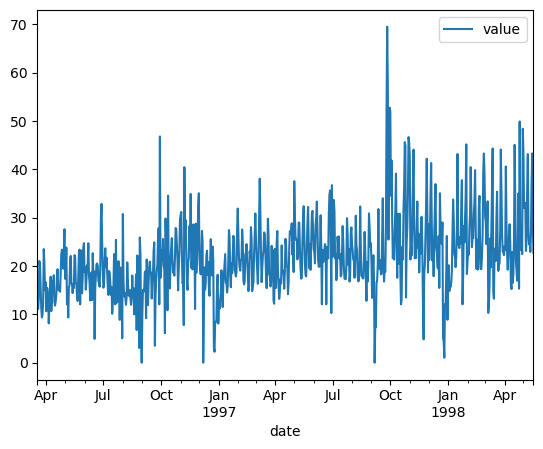

In [64]:
# --- Your code here ---
df[df['id'] == 92].plot(x='date', y='value')

Постройте графики автокорреляций (ACF) и частных автокорреляций (PACF) до 40-го лага для тренировочной выборки.

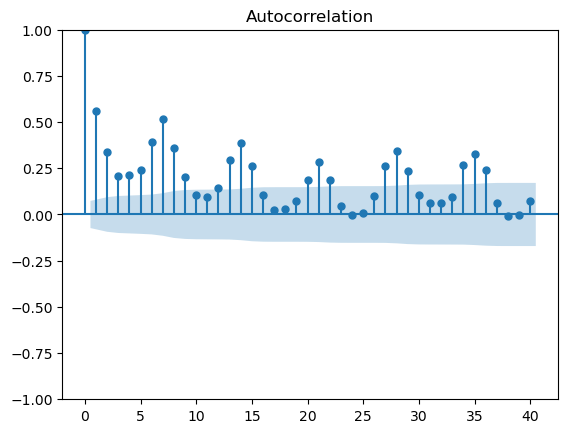

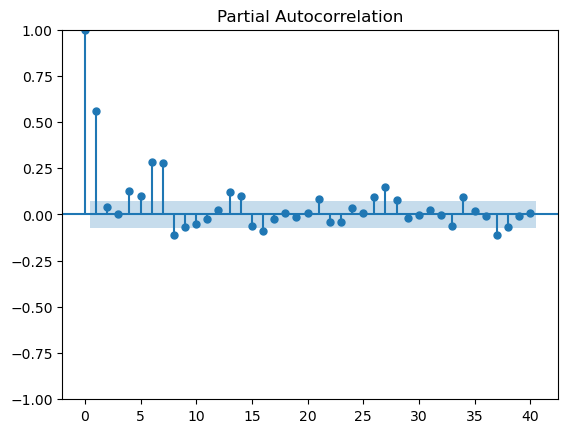

In [115]:
# --- Your code here ---
series_92_train = (
    train_df[train_df['id'] == 92]
    .sort_values('date')
    .set_index('date')['value']
)
plot_acf(series_92_train, lags=40)
plot_pacf(series_92_train, lags=40)
plt.show()

**Note**

Автокорелляция (acf) - показывает корелляцию между текущим значением ряда и им же t шагов назад, при этом когда мы задаём лаг, это максимальный t, для которого она считается. К примеру если у нас типичные данные по времени, было бы логично увидеть резкие скачки на значениях 7 и 30, т.к. данные между одними днями недели и днями месяца часто похожи (в большом числе случаев, но, разумеется, зависит от специфики данных).

Частичная автокорелляция (pacf) похожа на acf, однако она учитывает только непосредственные связи между двумя значениями t без учета промежуточных лагов. Так если t=1 не кореллирует с t=2, а t=2 и t=3 кореллируют сильно, то acf всё ещё покажет большую корелляцию t=1 и t=3, в то время как pacf покажет реальную нулевую корелляцию.

__Ответьте на следующие вопросы:__
- Стационарен ли временной ряд?
- Присутствует ли в нём тренд? Сезонность? Цикличность?
- Если ряд сезонный, то какой период выглядит наиболее вероятным?

**Ответы:**
- Нет, по причинам описанным далее.
- Да, по самому графику виден возрастающий тренд, по pacf - сезонность.
- 6-7 дней, то есть в один день недели показания обычно схожи.

#### Задание 2.2: Построение модели SARIMA (2 балла)

Пользуясь правилами отсюда: https://people.duke.edu/~rnau/arimrule.htm, попробуйте подобрать параметры SARIMA модели, как мы делали это на семинаре.

Не забудьте о возможности использовать предобработку данных, например, логарифмирование и удаление выбросов (самое простое — это воспользоваться IQR: https://medium.com/@divyansh9144/iqr-interquartile-range-for-anomaly-detection-f9c568d1195f).

Если вы используете предобработку, то обязательно укажите, какую именно и почему.

In [131]:
# --- Your code here ---
sarima = SARIMAX(series_92_train, order=(1,0,0), seasonal_order=(0,1,2,7),trend='ct')
res = sarima.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                        
==============================================================================================
Dep. Variable:                                  value   No. Observations:                  711
Model:             SARIMAX(1, 0, 0)x(0, 1, [1, 2], 7)   Log Likelihood               -2231.851
Date:                                Thu, 11 Jun 2026   AIC                           4475.703
Time:                                        13:29:50   BIC                           4503.043
Sample:                                    03-18-1996   HQIC                          4486.269
                                         - 02-26-1998                                         
Covariance Type:                                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0280      0.045      0.620      0.535      -0.060       0.116
drift       7.711e-05      0.000      0.689      0.491      -0.000       0.000
ar.L1          0.4714      0.018     25.891      0.000       0.436       0.507
ma.S.L7       -0.8757      0.031    -28.087      0.000      -0.937      -0.815
ma.S.L14      -0.0515      0.034     -1.526      0.127      -0.118       0.015
sigma2        31.2995      0.939     33.344      0.000      29.460      33.139
===================================================================================
Ljung-Box (L1) (Q):                   4.61   Jarque-Bera (JB):               782.77
Prob(Q):                              0.03   Prob(JB):                         0.00
Heteroskedasticity (H):               1.35   Skew:                             0.36
Prob(H) (two-sided):                  0.02   Kurtosis:                         8.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Задание 2.3: Анализ остатков (0.5 балла)

Постройте графики ACF и PACF остатков модели SARIMA. Проверьте, что в остатках нет значимых автокорреляций. Если они есть, то попробуйте объяснить, почему это происходит.

Проведите тест на стационарность остатков модели. Проведите тест на автокорреляцию остатков модели. Проинтерпретируйте результаты тестов. Если тесты показывают, что остатки нестационарны или в них есть автокорреляция, то попробуйте объяснить, почему это происходит.

<Axes: xlabel='date'>

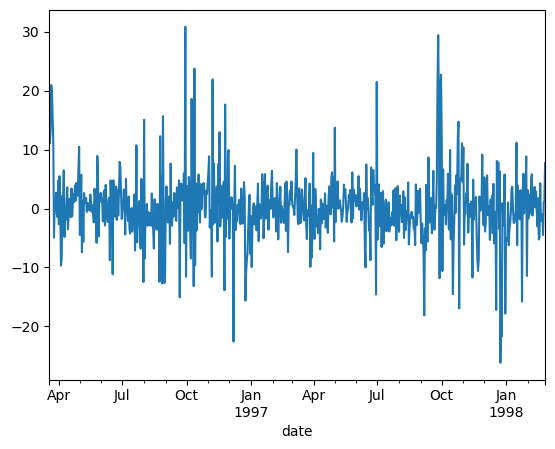

In [132]:
# --- Your code here ---
residuals = res.resid
residuals.plot()

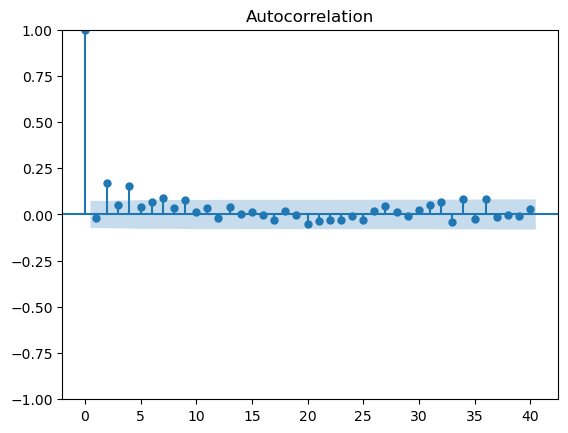

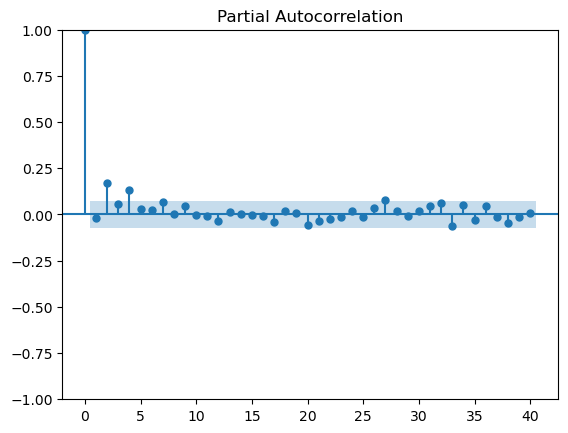

In [133]:
plot_acf(residuals, lags=40)
plot_pacf(residuals, lags=40)
plt.show()

In [134]:
adf_result = adfuller(residuals)

print("ADF statistic:", adf_result[0])
print("ADF p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("ADF: p-value < 0.05, отвергаем H0 о unit root. Остатки стационарны.")
else:
    print("ADF: p-value >= 0.05, не отвергаем H0. Есть признаки нестационарности остатков.")

ADF statistic: -8.8480593901591
ADF p-value: 1.6005919960887168e-14
ADF: p-value < 0.05, отвергаем H0 о unit root. Остатки стационарны.


In [135]:
kpss_result = kpss(residuals, regression='c', nlags='auto')

print("KPSS statistic:", kpss_result[0])
print("KPSS p-value:", kpss_result[1])

if kpss_result[1] > 0.05:
    print("KPSS: p-value > 0.05, не отвергаем H0 о стационарности. Остатки стационарны.")
else:
    print("KPSS: p-value <= 0.05, отвергаем H0. Есть признаки нестационарности остатков.")

KPSS statistic: 0.22217240264280838
KPSS p-value: 0.1
KPSS: p-value > 0.05, не отвергаем H0 о стационарности. Остатки стационарны.


In [136]:
ljung_box = acorr_ljungbox(
    residuals,
    lags=[7, 14, 21, 28, 40],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
7,49.062255,2.206119e-08
14,56.464367,4.842593e-07
21,60.366692,1.123776e-05
28,64.390804,1.087144e-04
40,83.062426,7.566109e-05


In [137]:
if (ljung_box['lb_pvalue'] > 0.05).all():
    print("Ljung-Box: p-values > 0.05. Значимой автокорреляции в остатках не обнаружено.")
else:
    print("Ljung-Box: есть p-values <= 0.05. В остатках остается значимая автокорреляция.")

Ljung-Box: есть p-values <= 0.05. В остатках остается значимая автокорреляция.


#### Задание 2.4: Получение прогнозов и выводы (1 балл)

С помощью полученной модели постройте прогноз на тестовую выборку.

Постройте график прогноза и фактических значений. Сделайте выводы о том, насколько хорошо модель предсказывает временной ряд.

Посчитайте метрику MASE, которую мы имплементировали в начале ноутбука. Объясните, что она показывает и почему ее потенциально полезнее использовать для сравнения моделей, чем MAE или MAPE. Выводы по самому значению метрики делать не нужно.

MASE: 1.0067002859444627


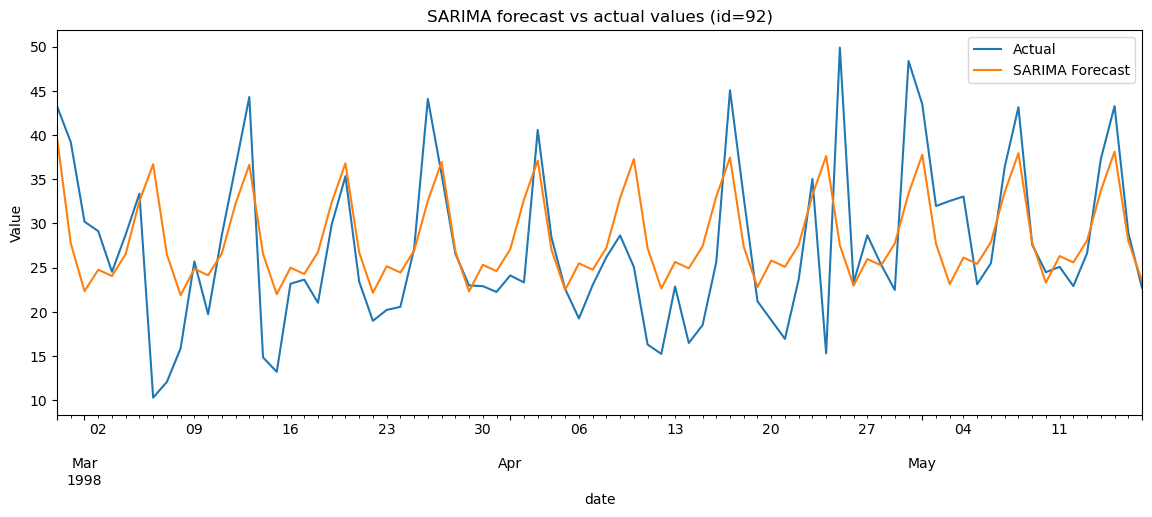

In [153]:
# --- Your code here ---
series_92_test = (
    test_df[test_df['id'] == 92]
    .sort_values('date')
    .set_index('date')['value']
)

forecast = res.get_forecast(
    steps=len(series_92_test)
).predicted_mean

forecast.index = series_92_test.index

print('MASE:', mase(forecast.to_numpy(), series_92_train.to_numpy(), series_92_test.to_numpy(), 7))

ax = series_92_test.plot(
    figsize=(14, 5),
    label='Actual'
)

forecast.plot(
    ax=ax,
    label='SARIMA Forecast'
)

plt.title('SARIMA forecast vs actual values (id=92)')
plt.ylabel('Value')
plt.legend()
plt.show()

**Вывод**

В целом модель справляется неплохо - во многом пики у нее в нужным местах, правда она по своей природе очень циклична, поэтому справляется хорошо когда данные ведут себя так же хорошо, а как только появляются отступления от общего тренда, модель справляться перестаёт.

В целом модель бы хотелось улучшить, так что скоро мы к этому перейдем.

**Почему MASE**

MASE удобен тем, что он нормируется на ошибку наивного прогноза (что значения идеально повторяются с некоторой периодичностью).

Даже по одному значению метрики уже можно увидеть, насколько модель лучше/хуже наивного прогноза, к примеру наша сарима показывает себя практически так же (или незначительно хуже).

### Задание 3. Построение бейзлайнов на всех рядах и автоматический подбор параметров (2 балла)

#### Задание 3.1: Запуск бейзлайнов (1 балл)
Давайте будем использовать statsforecast для бейзлайнов, так же как мы делали это на семинаре: https://nixtlaverse.nixtla.io/statsforecast/index.html

Постройте прогнозы на всех рядах с помощью следующих бейзлайнов:
- Naive
- Seasonal Naive
- AutoARIMA
- еще 2 на ваш выбор (например, ETS, Theta, TBATS или другие, которые вам нравятся). Кратко опишите суть выбранных моделей.

In [156]:
from statsforecast.models import Naive, SeasonalNaive, AutoARIMA, AutoETS, AutoTheta

# Переименуйте колонки, так как библиотека требует названия "unique_id", "y", "ds"
# --- Your code here ---
train_df = train_df.rename(columns={
        'id': 'unique_id',
        'date': 'ds',
        'value': 'y'
    })

test_df = test_df.rename(columns={
        'id': 'unique_id',
        'date': 'ds',
        'value': 'y'
    })

h = test_df.groupby('unique_id').size().min()

# Инициализируйте модели
# --- Your code here ---
season_length = 7

models = [
    Naive(),
    SeasonalNaive(season_length=season_length),
    AutoARIMA(season_length=season_length),
    AutoETS(season_length=season_length),
    AutoTheta(season_length=season_length),
]

sf = StatsForecast(
    models=models,
    freq='D',
    n_jobs=-1
)


# Получите прогнозы
# --- Your code here ---

forecasts_df = sf.forecast(
    df=train_df,
    h=h
)

forecasts_df.head()

/Users/ashentide/anaconda3/lib/python3.13/site-packages/statsforecast/arima.py:1882: UserWarning: Stepwise search was stopped early due to reaching the model number limit: nmodels=94
  warnings.warn(


,unique_id,ds,Naive,SeasonalNaive,AutoARIMA,AutoETS,AutoTheta
0,0,1998-02-27,62.471655,42.219388,43.981682,42.371708,42.999105
1,0,1998-02-28,62.471655,30.938209,29.586172,29.602472,31.460485
2,0,1998-03-01,62.471655,25.864512,27.343695,28.477031,31.664138
3,0,1998-03-02,62.471655,21.230159,23.755054,25.256084,28.034582
4,0,1998-03-03,62.471655,29.733560,32.315028,33.060506,33.840918


#### Задание 3.2: Анализ результатов (1 балл)

Постройте графики фактических значений и прогнозов для всех бейзлайнов для ряда 92. Выведите метрики MASE.

Что можно сказать о каждом из бейзлайнов? Какой из бейзлайнов лучше всего предсказывает временной ряд?

Смогли ли вы руками подобрать гиперпараметры для SARIMA модели лучше, чем автоматический подбор в библиотеке? Если да, то вы огромный молодец! Если нет, то не расстраивайтесь, так бывает.

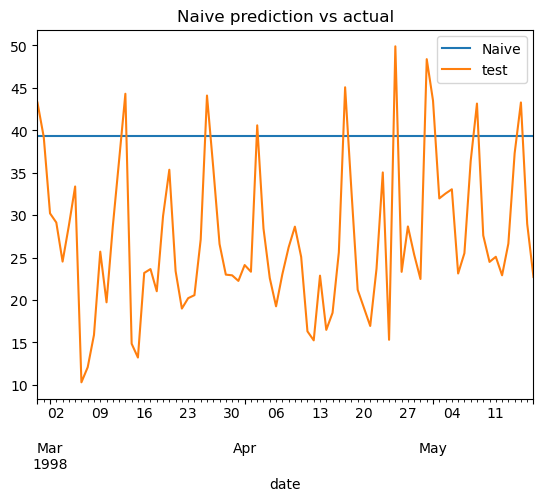

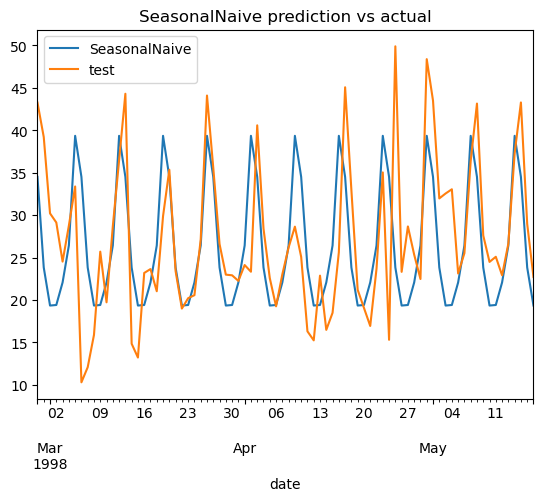

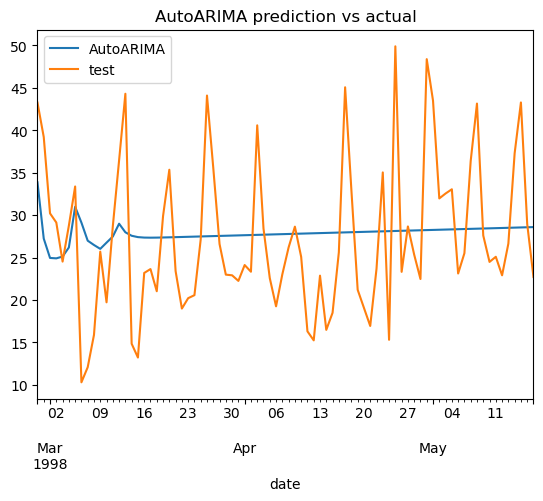

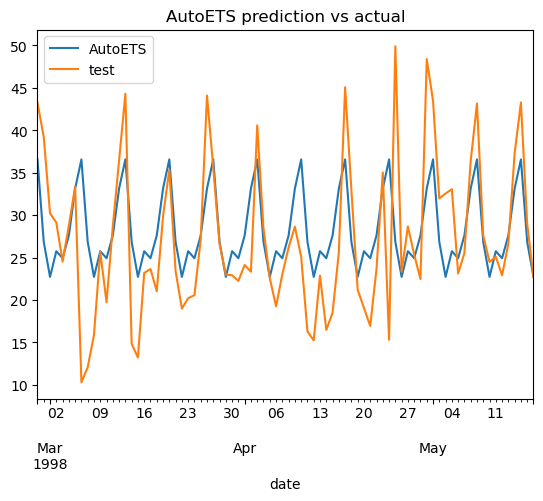

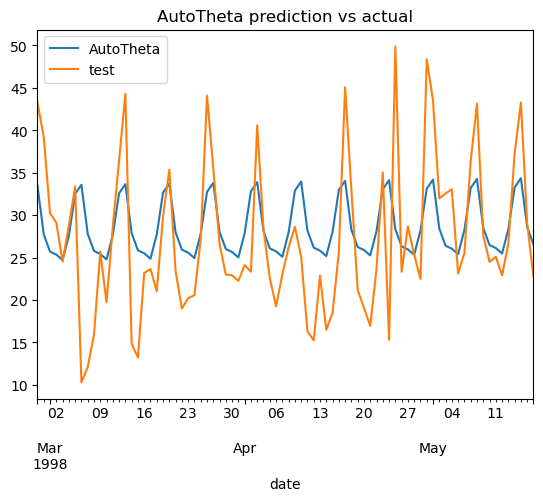

In [180]:
# --- Your code here ---
forecasts_df_92 = forecasts_df[forecasts_df['unique_id'] == 92]
forecasts_df_92.set_index('ds')

methods = [x for x in forecasts_df_92.columns if x not in ['unique_id', 'ds']]

for method in methods:
    fig, ax = plt.subplots()    

    forecasts_df_92.plot(x='ds', y=method, ax=ax)
    series_92_test.plot(ax=ax, label='test')

    plt.title(f'{method} prediction vs actual')
    plt.legend()
    plt.show()

Постройте датафрейм с MASE для всех бейзлайнов (агрегированный по всем рядам). Какой из бейзлайнов лучше всего предсказывает временные ряды в нашем датасете? Какой из бейзлайнов хуже всего предсказывает временные ряды в нашем датасете? Как вы думаете, почему так происходит?

In [175]:
# --- Your code here ---
frequency = 7

rows = []
for method in methods:
    mase_values = []

    for uid in forecasts_df["unique_id"].unique():
        forecast_uid = (
            forecasts_df[forecasts_df["unique_id"] == uid]
            .sort_values("ds")
        )
        train_uid = (
            train_df[train_df["unique_id"] == uid]
            .sort_values("ds")
        )
        test_uid = (
            test_df[test_df["unique_id"] == uid]
            .sort_values("ds")
        )

        forecast = forecast_uid[method].to_numpy()
        insample = train_uid["y"].to_numpy()
        outsample = test_uid["y"].to_numpy()

        mase_value = mase(
            forecast=forecast,
            insample=insample,
            outsample=outsample,
            frequency=frequency,
        )

        mase_values.append(mase_value)

    rows.append({
        "method": method,
        "MASE": np.mean(mase_values)
    })

mase_df = (
    pd.DataFrame(rows)
    .sort_values("MASE")
    .reset_index(drop=True)
)

mase_df

,method,MASE
0,AutoETS,0.848850
1,AutoTheta,0.849804
2,AutoARIMA,0.854572
3,SeasonalNaive,1.003310
4,Naive,3.327772


**Вывод**

Хуже всего справляется наивный подход, как и ожидалось - он слишком простой.

Дальше идет сезонный наивный, который справляется достаточно неплохо, но всё ещё можно лучше.

И оставшиеся три метода справляются крайне похоже, но чуть вперед выбивается AutoETS. Он хорошо работает при стабильном уровне с выраженной сезонностью, и мы как раз замечали такое, когда сами смотрели на графики. Но в целом методы дают очень похожие результаты и все достаточно хороши. Однако можно лучше!

Постройте графики фактических значений и прогнозов самого сильного бейзлайна для еще 3-х каких-нибудь рядов и ответьте на следующие вопросы:
- Есть ли среди них такие, которые предсказываются хуже остальных?
- Есть ли среди них такие, которые предсказываются лучше остальных?

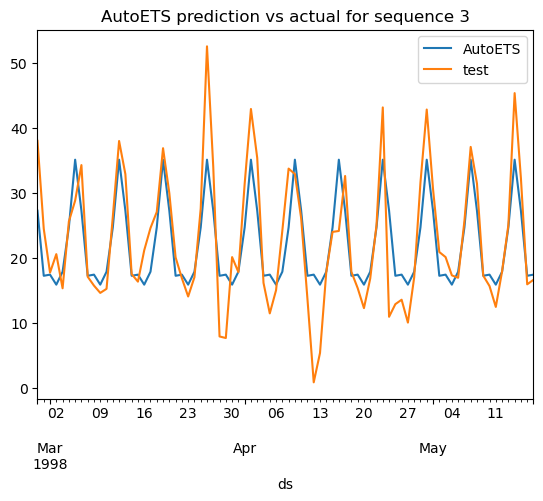

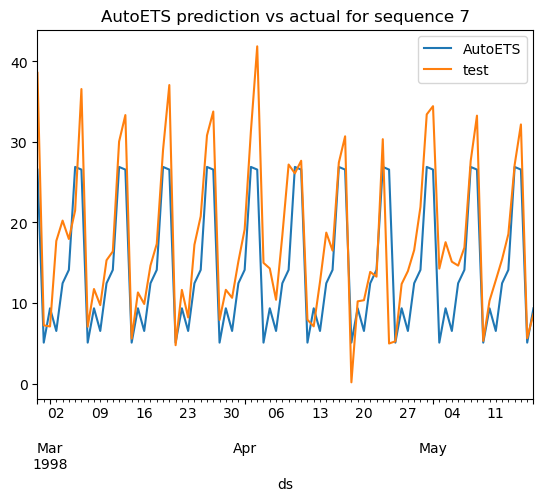

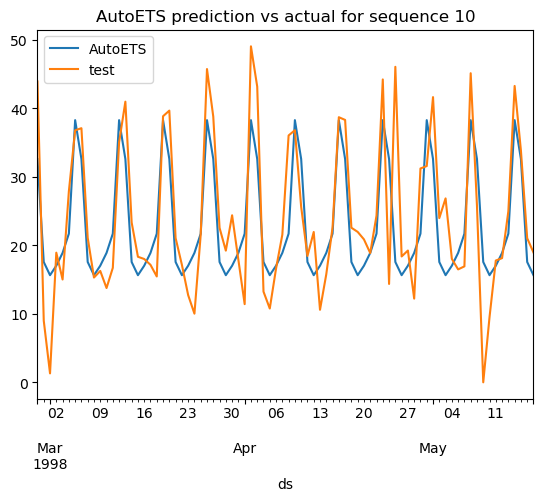

In [186]:
# --- Your code here ---
ids = [3,7,10]

for id in ids:
    fig, ax = plt.subplots()

    forecast_with_id = forecasts_df[forecasts_df['unique_id'] == id]
    test_with_id = test_df[test_df['unique_id'] == id]

    forecast_with_id.plot(x='ds', y='AutoETS', ax=ax)
    test_with_id.plot(ax=ax, label='test', x='ds', y='y')

    plt.title(f'AutoETS prediction vs actual for sequence {id}')
    plt.legend()
    plt.show()

- Есть ли среди них такие, которые предсказываются хуже остальных?

Да, к примеру рассмотренный ранее 92 ряд, да и 7 оставляет желать лучшего..

- Есть ли среди них такие, которые предсказываются лучше остальных?

Да, ряды 3 и 10.

### Задание 4. ML & DL модели (3 балла)

Здесь хочется дать вам полную свободу действий.

Вам нужно будет выбрать одну из ML моделей и одну из DL моделей (старайтесь не повторять один в один решение из семинара, а, если повторяете, то попробуйте, например, перебрать параметры DL модели, оптимизации, препроцессинга / добавить экзогенные признаки (актуально для MIMO стратегии) и т. д.) и построить прогнозы для всех временных рядов на тестовой выборке. __Ваша цель (желательная, но необязательная) — улучшить MASE, полученный с помощью бейзлайнов.__

__Результат задания — мини-отчет по тому, что вы попробовали, что получилось и что не получилось.__ По одному баллу дается за работу с данными (предобработка, генерация дополнительных признаков), за применение ML и DL моделей и интерпретацию полученных с помощью них результатов. Не забудьте кратко описать суть выбранных моделей (особенно, если речь идет о DL моделях).

Вы можете использовать любые модели и библиотеки (`tsfresh` для извлечения признаков, `Tsururu` / `ETNA` / `darts` для использования предобработки, стратегий, моделей и т. д.).

#### Подготовка данных

In [25]:
train_df

,id,value,date
0,0,13.407029,1996-03-18
1,0,14.725057,1996-03-19
2,0,20.564059,1996-03-20
3,0,34.708050,1996-03-21
4,0,26.629819,1996-03-22
...,...,...,...
87716,110,10.099947,1998-02-22
87717,110,10.915308,1998-02-23
87718,110,14.452920,1998-02-24
87719,110,18.279853,1998-02-25


In [31]:
# --- Your code here --
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import EfficientFCParameters

extracted_features_train = extract_features(train_df, 
                                      column_id="id", 
                                      column_sort="date", 
                                      column_value='value', 
                                      default_fc_parameters=EfficientFCParameters())

impute(extracted_features_train)

extracted_features_train.reset_index(names='id', inplace=True)

extracted_features_train

Feature Extraction: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:23<00:00,  1.17it/s]


,id,value__variance_larger_than_standard_deviation,value__has_duplicate_max,value__has_duplicate_min,value__has_duplicate,value__sum_values,value__abs_energy,value__mean_abs_change,value__mean_change,value__mean_second_derivative_central,...,value__fourier_entropy__bins_5,value__fourier_entropy__bins_10,value__fourier_entropy__bins_100,value__permutation_entropy__dimension_3__tau_1,value__permutation_entropy__dimension_4__tau_1,value__permutation_entropy__dimension_5__tau_1,value__permutation_entropy__dimension_6__tau_1,value__permutation_entropy__dimension_7__tau_1,value__query_similarity_count__query_None__threshold_0.0,value__mean_n_absolute_max__number_of_maxima_7
0,0,1.0,0.0,1.0,1.0,19625.688995,637785.286939,9.259788,0.069105,0.012893,...,0.079983,0.136002,0.999282,1.647590,2.728841,3.774035,4.630402,5.321182,0.0,64.854632
1,1,1.0,0.0,1.0,1.0,12273.636779,239207.362104,5.111186,0.030281,0.007286,...,0.136002,0.181214,1.696791,1.724247,2.922762,4.157397,5.227506,6.004630,0.0,37.823939
2,2,1.0,0.0,1.0,1.0,14983.568813,393195.038566,8.584863,0.065812,0.001819,...,0.079983,0.136002,0.767423,1.653597,2.694597,3.553414,4.286497,4.891381,0.0,54.241578
3,3,1.0,0.0,1.0,1.0,14545.595691,348855.787343,7.194487,0.057069,0.023577,...,0.136002,0.181214,1.017793,1.680623,2.798222,3.907226,4.889462,5.616174,0.0,48.147473
4,4,1.0,0.0,1.0,1.0,14097.205373,350618.785529,8.228920,0.053017,0.014432,...,0.125256,0.181214,1.120906,1.674904,2.771246,3.821973,4.748651,5.450267,0.0,55.832928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,106,1.0,0.0,1.0,1.0,11924.282743,237662.401384,6.553478,0.029263,0.006816,...,0.249958,0.380783,1.861527,1.661794,2.762630,3.786644,4.658453,5.390535,0.0,43.822886
107,107,1.0,0.0,1.0,1.0,12534.031066,253355.108211,6.184578,0.026249,0.006846,...,0.204871,0.294982,1.794359,1.706779,2.819654,3.858706,4.757722,5.497134,0.0,38.494088
108,108,1.0,0.0,0.0,1.0,18743.378746,596045.664292,10.460714,0.062877,0.010574,...,0.125256,0.181214,0.890711,1.724125,2.808693,3.749114,4.552266,5.225815,0.0,63.530531
109,109,1.0,0.0,1.0,1.0,16181.800045,446164.540762,5.763829,0.006946,0.000530,...,0.136002,0.215617,1.501735,1.752061,3.038921,4.454358,5.602466,6.270795,0.0,52.465986


In [ ]:
for lag in range(1, 8):
    train_df[f"lag_{lag}"] = train_df.groupby("id")["value"].shift(lag)

for window in [3, 7, 30]:
    train_df[f"rolling_mean_{window}"] = (
        train_df.groupby("id")["value"]
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )

train_df["dayofweek"] = train_df["date"].dt.dayofweek

train_df["mean_same_dayofweek_prev"] = (
    train_df.groupby(["id", "dayofweek"])["value"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

train_df = train_df.merge(
    extracted_features_train,
    on='id',
    how='left'
)

train_df.head()

,id,value,date,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,...,value__fourier_entropy__bins_5,value__fourier_entropy__bins_10,value__fourier_entropy__bins_100,value__permutation_entropy__dimension_3__tau_1,value__permutation_entropy__dimension_4__tau_1,value__permutation_entropy__dimension_5__tau_1,value__permutation_entropy__dimension_6__tau_1,value__permutation_entropy__dimension_7__tau_1,value__query_similarity_count__query_None__threshold_0.0,value__mean_n_absolute_max__number_of_maxima_7
0,0,13.407029,1996-03-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632
1,0,14.725057,1996-03-19,13.407029,NaN,NaN,NaN,NaN,NaN,NaN,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632
2,0,20.564059,1996-03-20,14.725057,13.407029,NaN,NaN,NaN,NaN,NaN,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632
3,0,34.708050,1996-03-21,20.564059,14.725057,13.407029,NaN,NaN,NaN,NaN,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632
4,0,26.629819,1996-03-22,34.708050,20.564059,14.725057,13.407029,NaN,NaN,NaN,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632


In [33]:
train_df = train_df.dropna(
    subset=[f"lag_{lag}" for lag in range(1, 8)]
).reset_index(drop=True)

fill_cols = [
    "rolling_mean_3",
    "rolling_mean_7",
    "mean_same_dayofweek_prev",
    "rolling_mean_30"
]

for col in fill_cols:
    train_df[col] = train_df[col].fillna(
        train_df.groupby("id")["value"].transform("mean")
    )

train_df.head()

,id,value,date,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,...,value__fourier_entropy__bins_5,value__fourier_entropy__bins_10,value__fourier_entropy__bins_100,value__permutation_entropy__dimension_3__tau_1,value__permutation_entropy__dimension_4__tau_1,value__permutation_entropy__dimension_5__tau_1,value__permutation_entropy__dimension_6__tau_1,value__permutation_entropy__dimension_7__tau_1,value__query_similarity_count__query_None__threshold_0.0,value__mean_n_absolute_max__number_of_maxima_7
0,0,11.607143,1996-03-25,15.320295,16.609977,26.629819,34.708050,20.564059,14.725057,13.407029,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632
1,0,19.883787,1996-03-26,11.607143,15.320295,16.609977,26.629819,34.708050,20.564059,14.725057,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632
2,0,23.767007,1996-03-27,19.883787,11.607143,15.320295,16.609977,26.629819,34.708050,20.564059,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632
3,0,34.027778,1996-03-28,23.767007,19.883787,11.607143,15.320295,16.609977,26.629819,34.708050,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632
4,0,33.786848,1996-03-29,34.027778,23.767007,19.883787,11.607143,15.320295,16.609977,26.629819,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632


In [36]:
y_train = train_df['value']
x_train = train_df.drop(columns='value')

display(y_train)
x_train.head()

0        11.607143
1        19.883787
2        23.767007
3        34.027778
4        33.786848
           ...    
78139    10.099947
78140    10.915308
78141    14.452920
78142    18.279853
78143    27.472383
Name: value, Length: 78144, dtype: float64

,id,date,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean_3,...,value__fourier_entropy__bins_5,value__fourier_entropy__bins_10,value__fourier_entropy__bins_100,value__permutation_entropy__dimension_3__tau_1,value__permutation_entropy__dimension_4__tau_1,value__permutation_entropy__dimension_5__tau_1,value__permutation_entropy__dimension_6__tau_1,value__permutation_entropy__dimension_7__tau_1,value__query_similarity_count__query_None__threshold_0.0,value__mean_n_absolute_max__number_of_maxima_7
0,0,1996-03-25,15.320295,16.609977,26.629819,34.708050,20.564059,14.725057,13.407029,19.520030,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632
1,0,1996-03-26,11.607143,15.320295,16.609977,26.629819,34.708050,20.564059,14.725057,14.512472,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632
2,0,1996-03-27,19.883787,11.607143,15.320295,16.609977,26.629819,34.708050,20.564059,15.603741,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632
3,0,1996-03-28,23.767007,19.883787,11.607143,15.320295,16.609977,26.629819,34.708050,18.419312,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632
4,0,1996-03-29,34.027778,23.767007,19.883787,11.607143,15.320295,16.609977,26.629819,25.892857,...,0.079983,0.136002,0.999282,1.64759,2.728841,3.774035,4.630402,5.321182,0.0,64.854632


#### Построение модели ML

In [39]:
test_df

,id,value,date
711,0,45.493197,1998-02-27
712,0,33.489229,1998-02-28
713,0,18.608277,1998-03-01
714,0,24.333900,1998-03-02
715,0,26.927438,1998-03-03
...,...,...,...
87796,110,18.016833,1998-05-13
87797,110,25.157812,1998-05-14
87798,110,22.080484,1998-05-15
87799,110,10.113098,1998-05-16


In [37]:
import catboost

ModuleNotFoundError: No module named 'catboost'


Постройте графики фактических значений и прогнозов для всех бейзлайнов для ряда 92. Постройте графики фактических значений и прогнозов для 3-х рядов из предыдущего задания. Стали ли прогнозы лучше отражать реальность?

In [ ]:
# --- Your code here --